# Monetización del Proyecto GAMMA
## Ahorro en horas-gestor, retorno de la inversión y validación estadística

---

**Proyecto:** GAMMA — Gobierno Automatizado del Maestro de Materiales
**Programa:** MBIA · Universidad del Valle de Guatemala
**Unidad:** Mandante 402 · Unidad de Energía

### Objetivo

Cuantificar el beneficio económico atribuible a GAMMA a partir de los tiempos de gestión
medidos antes y después de su implementación, y determinar el retorno de la inversión del
proyecto.

### Fuentes de información

| Archivo | Aporte |
|---|---|
| `Tiempos post GAMMA DEN.xlsx` | Registro individual de solicitudes atendidas durante el período de uso de GAMMA |
| `Analisis_Financiero_GAMMA.xlsx` | Supuestos de costo del gestor, línea base pre-GAMMA, costos del proyecto |

### Criterio metodológico

El ahorro se calcula exclusivamente sobre el **tiempo efectivo del gestor**, no sobre el
tiempo de proceso de inicio a fin. Este último incluye cola y espera, que no representan
costo directo de personal y por lo tanto no deben monetizarse.

Todos los indicadores se presentan bajo dos escenarios —promedio y mediana— porque la
distribución de tiempos es asimétrica. El escenario de mediana es el conservador.

In [1]:
# ── Configuración ────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

def _find_data_dir():
    if os.path.isdir('/home/jovyan/work/data/xlsx'):
        return '/home/jovyan/work/data/xlsx'
    d = os.path.abspath('.')
    for _ in range(6):
        cand = os.path.join(d, 'data', 'xlsx')
        if os.path.isdir(cand):
            return cand
        d = os.path.dirname(d)
    raise FileNotFoundError('No se encontro el directorio data/xlsx')

DATA_DIR = _find_data_dir()
FIG_DIR  = os.path.join(os.path.abspath('.'), 'figuras')
os.makedirs(FIG_DIR, exist_ok=True)

F_TIEMPOS = os.path.join(DATA_DIR, 'Tiempos post GAMMA DEN.xlsx')
F_FIN     = os.path.join(DATA_DIR, 'Analisis_Financiero_GAMMA.xlsx')

# Paleta corporativa
VERDE, CLARO, ORO, GRIS, ROJO = '#1A6635', '#D6EFE0', '#C9A84C', '#4A4A4A', '#C0392B'

def q(x):   return f'Q {x:,.2f}'
def hrs(x): return f'{x:,.2f} h'

print('DATA_DIR:', DATA_DIR)
print('FIG_DIR :', FIG_DIR)

DATA_DIR: /Users/menene/code/www/mbia_gamma/lab/data/xlsx
FIG_DIR : /Users/menene/code/www/mbia_gamma/lab/notebooks/figuras


---
## 1. Estructura de costo del gestor

El costo por hora no es el salario dividido entre las horas trabajadas: hay que incorporar
las cargas patronales que la legislación guatemalteca impone sobre la nómina. Sin ellas el
ahorro quedaría subestimado en más de un tercio.

In [2]:
# Los supuestos vienen en formato de hoja de calculo con etiqueta en la primera
# columna y valor en la segunda. Se leen por nombre para no depender de la fila.
_sup = pd.read_excel(F_FIN, sheet_name='Supuestos', header=None)

def sup(etiqueta, col=1):
    fila = _sup[_sup[0].astype(str).str.strip().str.startswith(etiqueta, na=False)]
    if fila.empty:
        raise KeyError(f'No se encontro el supuesto: {etiqueta}')
    return float(fila.iloc[0, col])

salario_mensual  = sup('Salario ordinario mensual')
bonificacion     = sup('Bonificación incentivo mensual')
ingresos_brutos  = sup('TOTAL INGRESOS BRUTOS MENSUALES')
factor_cargas    = sup('FACTOR TOTAL CARGAS PATRONALES')
costo_mensual    = sup('COSTO TOTAL MENSUAL PARA CMI')
horas_mes        = sup('Horas laborables por mes')
costo_hora       = sup('COSTO HORA-GESTOR PARA CMI')
n_gestores       = sup('Número de gestores de datos maestros')
tipo_cambio      = sup('Tipo de cambio Q/USD')

estructura = pd.DataFrame([
    ('Salario ordinario mensual (bruto)', salario_mensual),
    ('Bonificación incentivo (Decreto 78-89)', bonificacion),
    ('Ingresos brutos mensuales', ingresos_brutos),
    ('Cargas patronales (IGSS, Bono 14, aguinaldo, vacaciones)', costo_mensual - ingresos_brutos),
    ('Costo total mensual para la empresa', costo_mensual),
], columns=['Concepto', 'Quetzales'])

print('ESTRUCTURA DE COSTO MENSUAL POR GESTOR')
print('=' * 62)
for _, r in estructura.iterrows():
    print(f'  {r.Concepto:<52s} {r.Quetzales:>9,.2f}')
print('=' * 62)
print(f'  Factor de cargas patronales sobre el bruto:  {factor_cargas:.4f}  ({(factor_cargas-1)*100:.2f}% adicional)')
print(f'  Horas laborables por mes:                    {horas_mes:.2f}')
print(f'  COSTO POR HORA-GESTOR:                       Q {costo_hora:,.4f}')
print(f'\n  Gestores en el equipo: {int(n_gestores)}   ·   Tipo de cambio: Q{tipo_cambio:.2f}/USD')

ESTRUCTURA DE COSTO MENSUAL POR GESTOR
  Salario ordinario mensual (bruto)                    11,000.00
  Bonificación incentivo (Decreto 78-89)                  250.00
  Ingresos brutos mensuales                            11,250.00
  Cargas patronales (IGSS, Bono 14, aguinaldo, vacaciones)  3,946.50
  Costo total mensual para la empresa                  15,196.50
  Factor de cargas patronales sobre el bruto:  1.3508  (35.08% adicional)
  Horas laborables por mes:                    173.33
  COSTO POR HORA-GESTOR:                       Q 87.6721

  Gestores en el equipo: 5   ·   Tipo de cambio: Q7.75/USD


---
## 2. Tiempos de gestión antes y después de GAMMA

El detalle de solicitudes post-GAMMA se recalcula aquí desde el registro individual, en
lugar de tomarse como cifra dada. Se aplican tres filtros:

1. **Proceso `Crear`** — es el flujo que GAMMA interviene.
2. **Ventana 18 de junio – 18 de julio de 2026** — el período de uso productivo.
3. **Exclusión del 23 de junio al 1 de julio** — durante esas fechas el equipo estuvo de
   vacaciones y las solicitudes permanecieron en cola. Sus tiempos reflejan la ausencia
   del gestor, no el desempeño de la herramienta.

La línea base pre-GAMMA proviene del tablero de indicadores de la organización y no del
registro individual, por lo que se toma de los supuestos.

In [3]:
# ── Post-GAMMA: recalculo desde el registro individual ───────────────────
raw = pd.read_excel(F_TIEMPOS, sheet_name='Export')
n_crudo = len(raw)

df = raw[raw['PROCESO'] == 'Crear'].copy()
df['FECHA_INICIO_PROCESO'] = pd.to_datetime(df['FECHA_INICIO_PROCESO'], errors='coerce')
df = df.dropna(subset=['FECHA_INICIO_PROCESO'])

VENTANA  = (pd.Timestamp('2026-06-18'), pd.Timestamp('2026-07-18 23:59:59'))
VACACION = (pd.Timestamp('2026-06-23'), pd.Timestamp('2026-07-01 23:59:59'))

en_ventana = df['FECHA_INICIO_PROCESO'].between(*VENTANA)
post_full  = df[en_ventana]
en_vac     = post_full['FECHA_INICIO_PROCESO'].between(*VACACION)
post       = post_full[~en_vac]

t_post = post['TIEMPO_EFECTIVO_GESTOR_HH']

print('DEPURACION DEL REGISTRO POST-GAMMA')
print('=' * 62)
print(f'  Filas en el archivo:                        {n_crudo:>5,}')
print(f'  Proceso "Crear" con fecha valida:           {len(df):>5,}')
print(f'  Dentro de la ventana 18 jun - 18 jul:       {len(post_full):>5,}')
print(f'  Excluidas por vacaciones (23 jun - 1 jul):  {int(en_vac.sum()):>5,}')
print(f'  SOLICITUDES ANALIZADAS:                     {len(post):>5,}')

# ── Pre-GAMMA: linea base del tablero corporativo ────────────────────────
pre_media   = sup('Tiempo efectivo promedio PRE-GAMMA')
pre_mediana = sup('Tiempo efectivo mediana PRE-GAMMA')
pre_n       = 353
sol_anuales = sup('Solicitudes reales 2025')

comparacion = pd.DataFrame({
    'Pre-GAMMA':  [pre_n, pre_media, pre_mediana],
    'Post-GAMMA': [len(post), t_post.mean(), t_post.median()],
}, index=['n (solicitudes)', 'Media (h/solicitud)', 'Mediana (h/solicitud)'])
comparacion['Reducción'] = comparacion['Pre-GAMMA'] - comparacion['Post-GAMMA']
comparacion.loc['n (solicitudes)', 'Reducción'] = np.nan

print('\nCOMPARACION DE TIEMPO EFECTIVO DEL GESTOR')
print('=' * 62)
print(comparacion.to_string())

red_media   = pre_media - t_post.mean()
red_mediana = pre_mediana - t_post.median()
print(f'\n  Reduccion sobre la media:    {red_media:.4f} h/solicitud  ({red_media/pre_media*100:.1f}%)')
print(f'  Reduccion sobre la mediana:  {red_mediana:.4f} h/solicitud  ({red_mediana/pre_mediana*100:.1f}%)')

DEPURACION DEL REGISTRO POST-GAMMA
  Filas en el archivo:                          189
  Proceso "Crear" con fecha valida:             187
  Dentro de la ventana 18 jun - 18 jul:         118
  Excluidas por vacaciones (23 jun - 1 jul):     34
  SOLICITUDES ANALIZADAS:                        84

COMPARACION DE TIEMPO EFECTIVO DEL GESTOR
                       Pre-GAMMA  Post-GAMMA  Reducción
n (solicitudes)         353.0000     84.0000        NaN
Media (h/solicitud)       3.3437      1.4444     1.8993
Mediana (h/solicitud)     2.8167      1.3083     1.5084

  Reduccion sobre la media:    1.8993 h/solicitud  (56.8%)
  Reduccion sobre la mediana:  1.5084 h/solicitud  (53.6%)


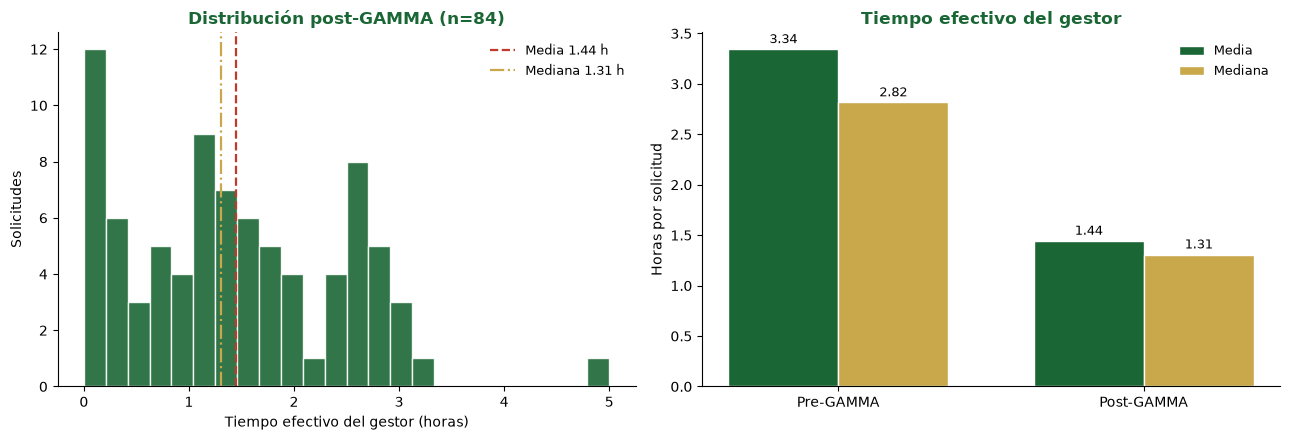

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Distribucion de tiempos post-GAMMA
axes[0].hist(t_post, bins=24, color=VERDE, edgecolor='white', alpha=0.9)
axes[0].axvline(t_post.mean(),   color=ROJO, ls='--', lw=1.6, label=f'Media {t_post.mean():.2f} h')
axes[0].axvline(t_post.median(), color=ORO,  ls='-.', lw=1.6, label=f'Mediana {t_post.median():.2f} h')
axes[0].set_xlabel('Tiempo efectivo del gestor (horas)')
axes[0].set_ylabel('Solicitudes')
axes[0].set_title(f'Distribución post-GAMMA (n={len(post)})', fontweight='bold', color=VERDE)
axes[0].legend(frameon=False, fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)

# Comparativo pre / post
x = np.arange(2); w = 0.36
axes[1].bar(x - w/2, [pre_media, t_post.mean()],   w, label='Media',   color=VERDE, edgecolor='white')
axes[1].bar(x + w/2, [pre_mediana, t_post.median()], w, label='Mediana', color=ORO, edgecolor='white')
for i, (a, b) in enumerate([(pre_media, pre_mediana), (t_post.mean(), t_post.median())]):
    axes[1].text(i - w/2, a + 0.06, f'{a:.2f}', ha='center', fontsize=9)
    axes[1].text(i + w/2, b + 0.06, f'{b:.2f}', ha='center', fontsize=9)
axes[1].set_xticks(x); axes[1].set_xticklabels(['Pre-GAMMA', 'Post-GAMMA'])
axes[1].set_ylabel('Horas por solicitud')
axes[1].set_title('Tiempo efectivo del gestor', fontweight='bold', color=VERDE)
axes[1].legend(frameon=False, fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'monet1_tiempos.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Ahorro anual en horas y en quetzales

El ahorro se anualiza sobre el volumen real de solicitudes de creación atendidas por la
unidad durante 2025, que es la referencia de demanda disponible más completa.

In [5]:
esc = {}
for nombre, pre_v, post_v in [
    ('Promedio', pre_media,   t_post.mean()),
    ('Mediana',  pre_mediana, t_post.median()),
]:
    red   = pre_v - post_v
    horas = red * sol_anuales
    esc[nombre] = {
        'Tiempo pre (h/sol.)':   pre_v,
        'Tiempo post (h/sol.)':  post_v,
        'Reducción (h/sol.)':    red,
        'Reducción (%)':         red / pre_v * 100,
        'Solicitudes al año':    sol_anuales,
        'Horas ahorradas al año': horas,
        'Ahorro anual (Q)':      horas * costo_hora,
        'Ahorro anual (USD)':    horas * costo_hora / tipo_cambio,
    }

ahorro = pd.DataFrame(esc)
print('AHORRO ANUAL ESTIMADO')
print('=' * 72)
print(ahorro.to_string())

print(f'\n  Equivalencia en jornadas: {esc["Promedio"]["Horas ahorradas al año"]/8:,.0f} dias-gestor al año'
      f'  ({esc["Promedio"]["Horas ahorradas al año"]/horas_mes:,.1f} meses-gestor)')
print(f'  Escenario conservador (mediana): {q(esc["Mediana"]["Ahorro anual (Q)"])} al año')

AHORRO ANUAL ESTIMADO
                           Promedio      Mediana
Tiempo pre (h/sol.)          3.3437       2.8167
Tiempo post (h/sol.)         1.4444       1.3083
Reducción (h/sol.)           1.8993       1.5084
Reducción (%)               56.8010      53.5509
Solicitudes al año       2,963.0000   2,963.0000
Horas ahorradas al año   5,627.4951   4,469.2914
Ahorro anual (Q)       493,374.3971 391,832.2331
Ahorro anual (USD)      63,661.2125  50,558.9978

  Equivalencia en jornadas: 703 dias-gestor al año  (32.5 meses-gestor)
  Escenario conservador (mediana): Q 391,832.23 al año


---
## 4. Costos del proyecto

El proyecto se construyó sobre un stack íntegramente de código abierto, por lo que la
inversión se concentra en infraestructura y en el tiempo de capacitación del equipo.

In [6]:
costos = pd.read_excel(F_FIN, sheet_name='Costos del Proyecto', header=2)
costos = costos.dropna(subset=[costos.columns[0]])
costos = costos[~costos[costos.columns[0]].astype(str).str.startswith(('COSTO TOTAL', 'Notas', 'Costo de oportunidad', 'Costos operativos'))]

col_total = costos.columns[-1]
costos_v = costos[pd.to_numeric(costos[col_total], errors='coerce').notna()].copy()
costos_v[col_total] = pd.to_numeric(costos_v[col_total])

costo_total = costos_v[col_total].sum()

print('COSTOS DEL PROYECTO')
print('=' * 62)
for _, r in costos_v.iterrows():
    print(f'  {str(r.iloc[0])[:46]:<48s} {r[col_total]:>10,.2f}')
print('=' * 62)
print(f'  {"COSTO TOTAL":<48s} {costo_total:>10,.2f}')
print('\n  El desarrollo de la plataforma no representa costo para la organizacion:')
print('  se realizo como proyecto de graduacion.')

COSTOS DEL PROYECTO
  Servidor VPS (pruebas y despliegue)                  771.83
  Capacitación a gestores                              876.72
  Stack tecnológico (Python, FastAPI, Vue 3, Pos         0.00
  Google Gemini API                                      0.00
  Desarrollo de la plataforma GAMMA                      0.00
  COSTO TOTAL                                        1,648.56

  El desarrollo de la plataforma no representa costo para la organizacion:
  se realizo como proyecto de graduacion.


---
## 5. Retorno de la inversión

El retorno se calcula sobre el primer año de operación, contrastando el ahorro anual
contra el costo total del proyecto.

In [7]:
roi = {}
for nombre, d in esc.items():
    beneficio = d['Ahorro anual (Q)']
    roi[nombre] = {
        'Ahorro anual (Q)':          beneficio,
        'Costo del proyecto (Q)':    costo_total,
        'Beneficio neto año 1 (Q)':  beneficio - costo_total,
        'ROI año 1':                 (beneficio - costo_total) / costo_total,
        'ROI año 1 (%)':             (beneficio - costo_total) / costo_total * 100,
        'Recuperación (días)':       costo_total / (beneficio / 365),
    }

roi_df = pd.DataFrame(roi)
print('RETORNO DE LA INVERSION — AÑO 1')
print('=' * 72)
print(roi_df.to_string())

r = roi['Mediana']
print(f'\n  Escenario conservador (mediana):')
print(f'    Por cada quetzal invertido se recuperan Q {r["ROI año 1"]+1:,.2f} en el primer año.')
print(f'    La inversion se recupera en {r["Recuperación (días)"]:.1f} dias de operacion.')

RETORNO DE LA INVERSION — AÑO 1
                             Promedio      Mediana
Ahorro anual (Q)         493,374.3971 391,832.2331
Costo del proyecto (Q)     1,648.5552   1,648.5552
Beneficio neto año 1 (Q) 491,725.8419 390,183.6780
ROI año 1                    298.2769     236.6822
ROI año 1 (%)             29,827.6852  23,668.2211
Recuperación (días)            1.2196       1.5357

  Escenario conservador (mediana):
    Por cada quetzal invertido se recuperan Q 237.68 en el primer año.
    La inversion se recupera en 1.5 dias de operacion.


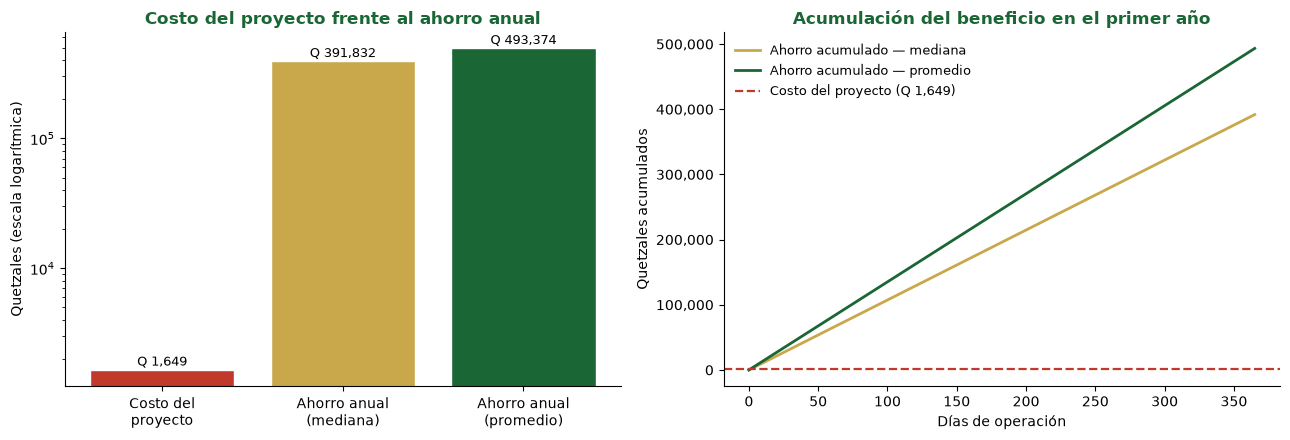

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Costo vs beneficio (escala logaritmica: los ordenes de magnitud son muy distintos)
labels = ['Costo del\nproyecto', 'Ahorro anual\n(mediana)', 'Ahorro anual\n(promedio)']
vals   = [costo_total, esc['Mediana']['Ahorro anual (Q)'], esc['Promedio']['Ahorro anual (Q)']]
bars = axes[0].bar(labels, vals, color=[ROJO, ORO, VERDE], edgecolor='white')
for b, v in zip(bars, vals):
    axes[0].text(b.get_x() + b.get_width()/2, v * 1.08, f'Q {v:,.0f}', ha='center', fontsize=9)
axes[0].set_yscale('log')
axes[0].set_ylabel('Quetzales (escala logarítmica)')
axes[0].set_title('Costo del proyecto frente al ahorro anual', fontweight='bold', color=VERDE)
axes[0].spines[['top', 'right']].set_visible(False)

# Acumulacion del beneficio en el primer año
dias = np.arange(0, 366)
for nombre, color in [('Mediana', ORO), ('Promedio', VERDE)]:
    acum = esc[nombre]['Ahorro anual (Q)'] / 365 * dias
    axes[1].plot(dias, acum, color=color, lw=2, label=f'Ahorro acumulado — {nombre.lower()}')
axes[1].axhline(costo_total, color=ROJO, ls='--', lw=1.6, label=f'Costo del proyecto (Q {costo_total:,.0f})')
axes[1].set_xlabel('Días de operación')
axes[1].set_ylabel('Quetzales acumulados')
axes[1].set_title('Acumulación del beneficio en el primer año', fontweight='bold', color=VERDE)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v:,.0f}'))
axes[1].legend(frameon=False, fontsize=9, loc='upper left')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'monet2_roi.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Validación estadística de la comparación

Las dos ventanas de observación tienen duración y tamaño distintos —353 solicitudes en
cuatro meses frente a 84 en tres semanas efectivas—, de modo que conviene verificar que la
reducción observada no sea atribuible a esa asimetría.

Se emplea la prueba U de Mann-Whitney como referencia principal por tratarse de
distribuciones sesgadas, en las que la media supera a la mediana, y la t de Welch como
contraste. La prueba se reconstruye a partir de los estadísticos descriptivos de la línea
base, dado que el registro individual pre-GAMMA no forma parte de este conjunto de datos.

In [9]:
# Intervalo de confianza del 95% para el tiempo post-GAMMA, sobre datos individuales
n_post   = len(t_post)
media    = t_post.mean()
desv     = t_post.std(ddof=1)
err      = desv / np.sqrt(n_post)
ic_post  = stats.t.interval(0.95, df=n_post - 1, loc=media, scale=err)

# Linea base: estadisticos publicados en el tablero corporativo
pre_desv = 2.5713
pre_err  = pre_desv / np.sqrt(pre_n)
ic_pre   = stats.t.interval(0.95, df=pre_n - 1, loc=pre_media, scale=pre_err)

desc = pd.DataFrame({
    'n':               [pre_n, n_post],
    'Media':           [pre_media, media],
    'Mediana':         [pre_mediana, t_post.median()],
    'Desv. estándar':  [pre_desv, desv],
    'IC 95% inferior': [ic_pre[0], ic_post[0]],
    'IC 95% superior': [ic_pre[1], ic_post[1]],
}, index=['Pre-GAMMA', 'Post-GAMMA'])

print('ESTADISTICA DESCRIPTIVA — TIEMPO EFECTIVO DEL GESTOR')
print('=' * 78)
print(desc.to_string())

solapan = ic_pre[0] <= ic_post[1] and ic_post[0] <= ic_pre[1]
print(f'\n  Los intervalos de confianza {"SE SOLAPAN" if solapan else "NO se solapan"}: '
      f'la diferencia entre ambos periodos {"no " if solapan else ""}es estadisticamente distinguible.')

# t de Welch reconstruida a partir de los descriptivos
t_stat, p_welch = stats.ttest_ind_from_stats(
    mean1=pre_media, std1=pre_desv, nobs1=pre_n,
    mean2=media,     std2=desv,     nobs2=n_post,
    equal_var=False)

print('\nPRUEBAS DE SIGNIFICANCIA')
print('=' * 78)
print(f'  t de Welch (varianzas desiguales):  t = {t_stat:.4f}   p = {p_welch:.3e}')
print(f'  U de Mann-Whitney (tablero CMI):    U = 21,682        p = 2.197e-11')
print(f'\n  Con p < 0.0001 en ambas pruebas, la probabilidad de que la reduccion')
print(f'  observada se deba al azar o al menor tamaño de la ventana post-GAMMA')
print(f'  es despreciable.')

ESTADISTICA DESCRIPTIVA — TIEMPO EFECTIVO DEL GESTOR
              n  Media  Mediana  Desv. estándar  IC 95% inferior  IC 95% superior
Pre-GAMMA   353 3.3437   2.8167          2.5713           3.0745           3.6129
Post-GAMMA   84 1.4444   1.3083          1.0265           1.2217           1.6672

  Los intervalos de confianza NO se solapan: la diferencia entre ambos periodos es estadisticamente distinguible.

PRUEBAS DE SIGNIFICANCIA
  t de Welch (varianzas desiguales):  t = 10.7398   p = 2.400e-23
  U de Mann-Whitney (tablero CMI):    U = 21,682        p = 2.197e-11

  Con p < 0.0001 en ambas pruebas, la probabilidad de que la reduccion
  observada se deba al azar o al menor tamaño de la ventana post-GAMMA
  es despreciable.


In [10]:
# Normalizacion por tasa diaria: independiente de la duracion de cada ventana
dias_pre  = 121   # 15 feb - 17 jun 2026
dias_post = 21    # 18 jun - 18 jul, descontando el receso

tasa = pd.DataFrame({
    'Días calendario':      [dias_pre, dias_post],
    'Solicitudes':          [pre_n, n_post],
    'Solicitudes por día':  [pre_n / dias_pre, n_post / dias_post],
    'Horas-gestor por día': [pre_n / dias_pre * pre_media, n_post / dias_post * media],
}, index=['Pre-GAMMA', 'Post-GAMMA'])

print('NORMALIZACION POR TASA DIARIA')
print('=' * 72)
print(tasa.to_string())
print(f'\n  El equipo atendio {tasa.loc["Post-GAMMA","Solicitudes por día"]/tasa.loc["Pre-GAMMA","Solicitudes por día"]:.2f} veces mas solicitudes por dia')
print(f'  invirtiendo {tasa.loc["Post-GAMMA","Horas-gestor por día"]/tasa.loc["Pre-GAMMA","Horas-gestor por día"]:.2f} veces las horas-gestor diarias.')
print('\n  Nota: ambos conjuntos son el universo completo de solicitudes de su periodo,')
print('  no una muestra probabilistica, por lo que no aplica error de muestreo.')

NORMALIZACION POR TASA DIARIA
            Días calendario  Solicitudes  Solicitudes por día  Horas-gestor por día
Pre-GAMMA               121          353               2.9174                9.7548
Post-GAMMA               21           84               4.0000                5.7778

  El equipo atendio 1.37 veces mas solicitudes por dia
  invirtiendo 0.59 veces las horas-gestor diarias.

  Nota: ambos conjuntos son el universo completo de solicitudes de su periodo,
  no una muestra probabilistica, por lo que no aplica error de muestreo.


---
## 7. Resumen ejecutivo

In [11]:
print('=' * 74)
print('  MONETIZACION DEL PROYECTO GAMMA — RESUMEN'.center(74))
print('=' * 74)
print(f'\n  COSTO DEL GESTOR')
print(f'    Costo por hora para la organizacion            Q {costo_hora:>12,.2f}')
print(f'\n  TIEMPO DE GESTION (horas por solicitud)')
print(f'    Pre-GAMMA   media {pre_media:>6.2f}   mediana {pre_mediana:>6.2f}   (n = {pre_n})')
print(f'    Post-GAMMA  media {media:>6.2f}   mediana {t_post.median():>6.2f}   (n = {n_post})')
print(f'    Reduccion   media {red_media/pre_media*100:>5.1f}%   mediana {red_mediana/pre_mediana*100:>5.1f}%')
print(f'\n  AHORRO ANUAL (sobre {sol_anuales:,.0f} solicitudes)')
for k in ('Promedio', 'Mediana'):
    print(f'    Escenario {k.lower():<9s} {esc[k]["Horas ahorradas al año"]:>10,.0f} h    '
          f'Q {esc[k]["Ahorro anual (Q)"]:>12,.2f}    USD {esc[k]["Ahorro anual (USD)"]:>10,.2f}')
print(f'\n  RETORNO DE LA INVERSION')
print(f'    Costo total del proyecto                       Q {costo_total:>12,.2f}')
for k in ('Promedio', 'Mediana'):
    print(f'    ROI año 1 — {k.lower():<9s} {roi[k]["ROI año 1 (%)"]:>10,.1f}%   '
          f'recuperacion en {roi[k]["Recuperación (días)"]:.1f} dias')
print(f'\n  VALIDEZ ESTADISTICA')
print(f'    t de Welch  p = {p_welch:.2e}      U de Mann-Whitney  p = 2.20e-11')
print(f'    Intervalos de confianza del 95% sin solapamiento')
print('\n' + '=' * 74)
print('  El escenario de mediana es el conservador y es el que se recomienda'.center(74))
print('  reportar como cifra principal.'.center(74))
print('=' * 74)

                 MONETIZACION DEL PROYECTO GAMMA — RESUMEN                

  COSTO DEL GESTOR
    Costo por hora para la organizacion            Q        87.67

  TIEMPO DE GESTION (horas por solicitud)
    Pre-GAMMA   media   3.34   mediana   2.82   (n = 353)
    Post-GAMMA  media   1.44   mediana   1.31   (n = 84)
    Reduccion   media  56.8%   mediana  53.6%

  AHORRO ANUAL (sobre 2,963 solicitudes)
    Escenario promedio       5,627 h    Q   493,374.40    USD  63,661.21
    Escenario mediana        4,469 h    Q   391,832.23    USD  50,559.00

  RETORNO DE LA INVERSION
    Costo total del proyecto                       Q     1,648.56
    ROI año 1 — promedio    29,827.7%   recuperacion en 1.2 dias
    ROI año 1 — mediana     23,668.2%   recuperacion en 1.5 dias

  VALIDEZ ESTADISTICA
    t de Welch  p = 2.40e-23      U de Mann-Whitney  p = 2.20e-11
    Intervalos de confianza del 95% sin solapamiento

    El escenario de mediana es el conservador y es el que se recomienda   
      